# Iris Flower Classification

## 1. Introduction

This project focuses on classifying Iris flowers into three different species using machine learning classification algorithms. The Iris dataset contains measurements of sepal and petal characteristics, which are used as input features to predict the flower species.

## 2. Objective

The objective of this project is to explore the Iris dataset, perform exploratory data analysis, train multiple classification models, evaluate their performance, and identify the best-performing model using standard classification metrics.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
df["target"] = iris.target

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Dataset Description

The Iris dataset is a well-known dataset available through the scikit-learn library. It contains 150 flower samples belonging to three species: Setosa, Versicolor, and Virginica.

The dataset contains four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target variable represents the flower species.

In [2]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

# Display the column names
print("\nColumn Names:")
print(df.columns)

# Display basic information
print("\nDataset Information:")
df.info()

Dataset Shape: (150, 5)

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### 3.1 Data Quality Check

The dataset was checked for missing values to ensure that the data is complete and suitable for machine learning analysis.

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [4]:
# Display the complete dataset
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
# Display the number of rows and columns
print("Number of rows and columns:", df.shape)

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display basic statistical information
print("\nStatistical Summary:")
df.describe()

Number of rows and columns: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Check for missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


### 3.2 Target Class Distribution

The target variable was analyzed to identify the different Iris flower species and the number of samples belonging to each class.

In [7]:
# Display the unique target classes
print("Unique target classes:")
print(df["target"].unique())

# Count the number of samples in each class
print("\nNumber of samples in each class:")
print(df["target"].value_counts())

Unique target classes:
[0 1 2]

Number of samples in each class:
target
0    50
1    50
2    50
Name: count, dtype: int64


### 3.3 Species Label Mapping

The numerical target values were mapped to their corresponding Iris species names to make the dataset easier to interpret during analysis and visualization.

In [8]:
# Map target numbers to actual flower species
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the relationships between the different flower features and examine how the measurements vary across the three Iris species.

The analysis includes pairwise feature visualization, boxplots, and comparison of average feature measurements across species.

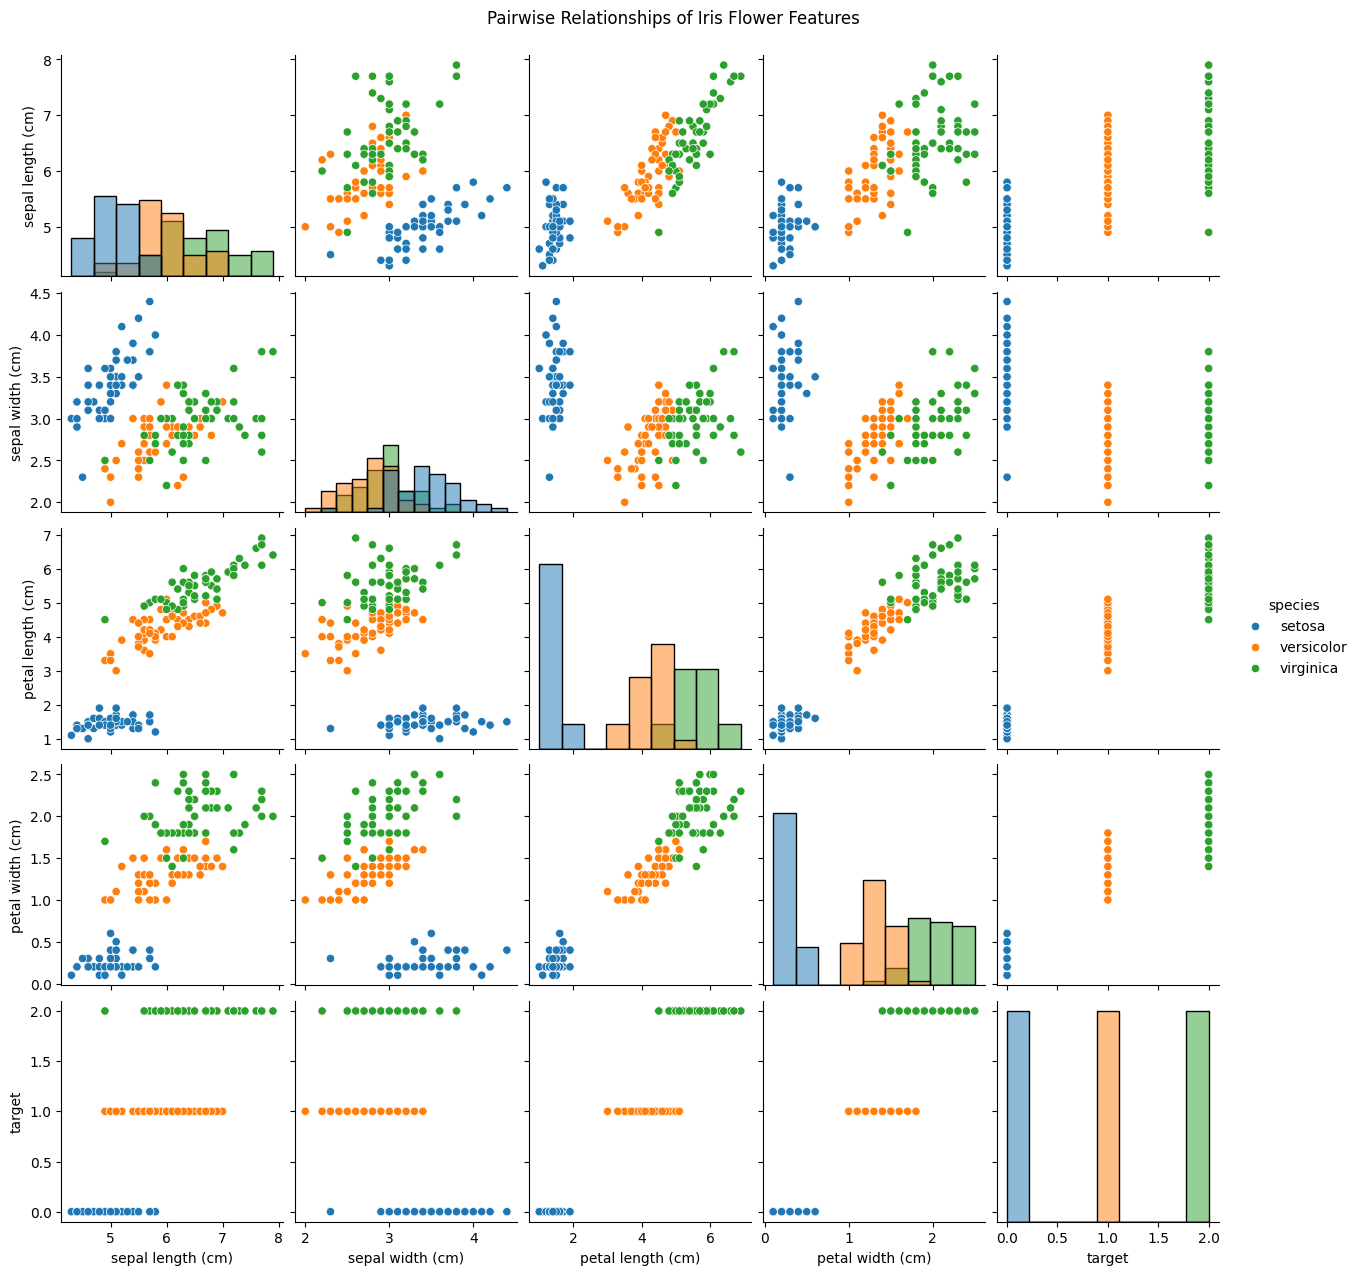

In [9]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pairplot to visualize relationships between features
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

# Add a title
plt.suptitle(
    "Pairwise Relationships of Iris Flower Features",
    y=1.02
)

# Display the plot
plt.show()

### 4.1 Feature Distribution Analysis

Boxplots were created to examine the distribution of the numerical features and identify the spread and potential outliers in the dataset.

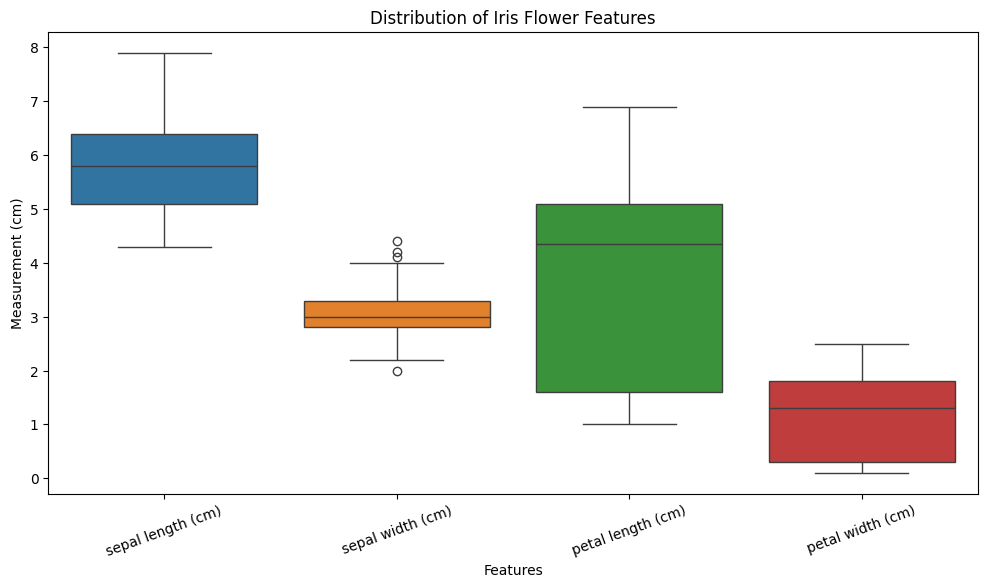

In [10]:
# Create boxplots for the numerical features
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        [
            "sepal length (cm)",
            "sepal width (cm)",
            "petal length (cm)",
            "petal width (cm)"
        ]
    ]
)

plt.title("Distribution of Iris Flower Features")
plt.xlabel("Features")
plt.ylabel("Measurement (cm)")

plt.xticks(rotation=20)

plt.show()

### 4.2 Average Feature Measurements by Species

The average measurements of sepal and petal features were calculated for each Iris species to compare their characteristics.

In [12]:
# Calculate the average measurements for each flower species
species_means = df.groupby("species")[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
].mean()

# Display the average measurements
species_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


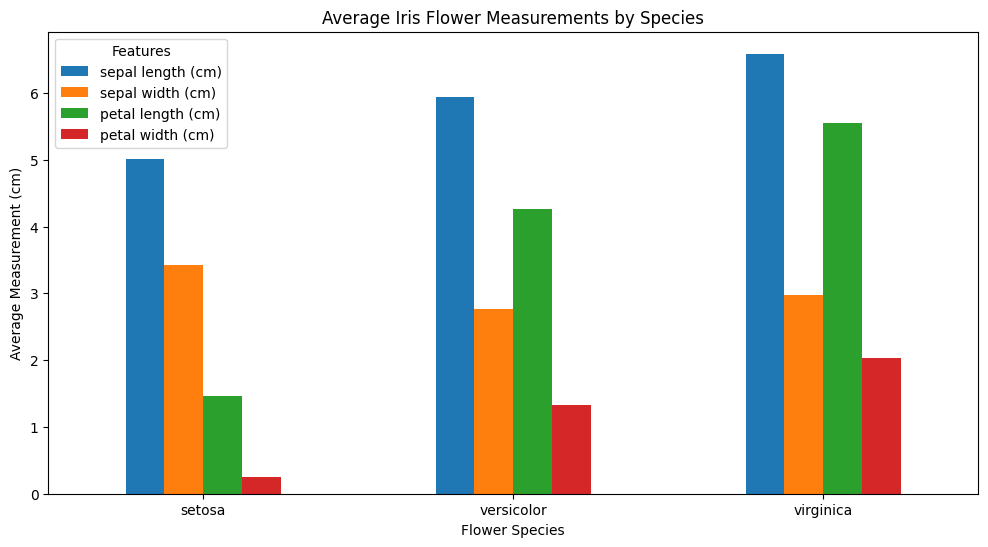

In [13]:
# Create a bar chart of average measurements by species
species_means.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Iris Flower Measurements by Species")
plt.xlabel("Flower Species")
plt.ylabel("Average Measurement (cm)")

plt.xticks(rotation=0)
plt.legend(title="Features")

plt.show()

## 5. Feature and Target Selection

The four numerical flower measurements were selected as input features. The target variable represents the Iris flower species that the machine learning models are required to predict.

In [14]:
# Select the input features
X = df[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
]

# Select the target variable
y = df["target"]

# Display the shape of X and y
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (150, 4)
Target (y) shape: (150,)


## 6. Train-Test Split

The dataset was divided into training and testing sets. 80% of the data was used for training the models, while 20% was reserved for testing their performance on unseen data.

In [15]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


## 7. Model 1: Logistic Regression

Logistic Regression was used as the first classification algorithm to predict the species of Iris flowers based on their sepal and petal measurements.

In [16]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
# Make predictions using the Logistic Regression model
y_pred_logistic = logistic_model.predict(X_test)

# Display the predictions
print("Predicted classes:")
print(y_pred_logistic)

Predicted classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


### 7.1 Logistic Regression Evaluation

The Logistic Regression model was evaluated using accuracy, precision, recall, F1-score, and a classification report. A confusion matrix was also created to analyze the model's classification performance.

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, average="weighted")
recall_logistic = recall_score(y_test, y_pred_logistic, average="weighted")
f1_logistic = f1_score(y_test, y_pred_logistic, average="weighted")

# Display the results
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy:  {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall:    {recall_logistic:.4f}")
print(f"F1-Score:  {f1_logistic:.4f}")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names
))

Logistic Regression Performance
--------------------------------
Accuracy:  0.9667
Precision: 0.9697
Recall:    0.9667
F1-Score:  0.9666

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



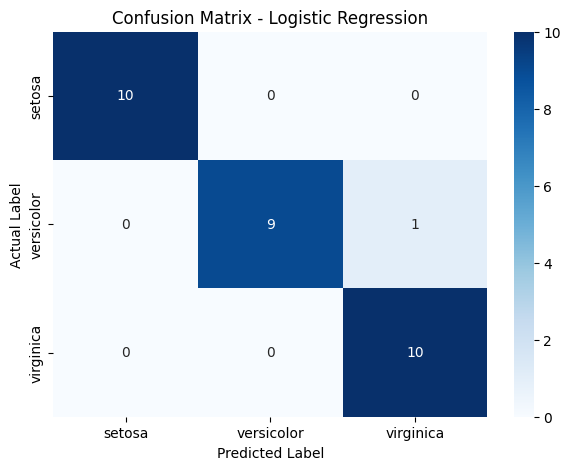

In [19]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 8. Model 2: Random Forest Classifier

Random Forest Classifier was used as the second machine learning algorithm. The model combines multiple decision trees to perform classification and was evaluated against the Logistic Regression model.



In [20]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
# Make predictions using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test)

# Display the predictions
print("Random Forest predictions:")
print(y_pred_rf)

Random Forest predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


### 8.1 Random Forest Evaluation

The Random Forest model was evaluated using accuracy, precision, recall, F1-score, and a classification report. A confusion matrix was also generated to examine the classification results.

In [22]:
# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

# Display the results
print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=iris.target_names
))

Random Forest Performance
-------------------------
Accuracy:  0.9000
Precision: 0.9024
Recall:    0.9000
F1-Score:  0.8997

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



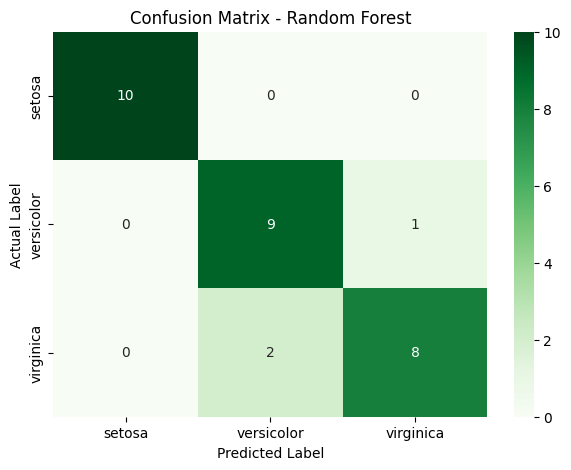

In [23]:
# Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 9. Model Comparison

The performance of Logistic Regression and Random Forest was compared using accuracy, precision, recall, and F1-score. The model with the strongest overall performance was selected as the best-performing classifier.

In [24]:
# Create a comparison table for both models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_rf
    ],
    "F1-Score": [
        f1_logistic,
        f1_rf
    ]
})

# Display the comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.966667,0.969697,0.966667,0.966583
1,Random Forest,0.900000,0.902357,0.900000,0.899749


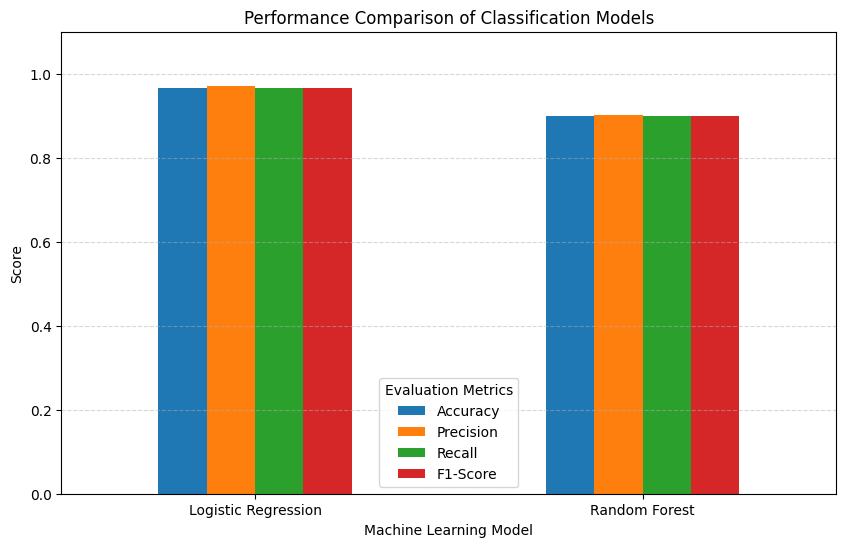

In [25]:
# Prepare data for visualization
comparison_plot = model_comparison.set_index("Model")

# Create a bar chart
comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1.1)
plt.xticks(rotation=0)

plt.legend(title="Evaluation Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 10. Best Model Selection

The best-performing model was identified by comparing the F1-scores of both classification models.

In [26]:
# Identify the best-performing model based on F1-score
best_model = model_comparison.loc[
    model_comparison["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.966667
Precision               0.969697
Recall                  0.966667
F1-Score                0.966583
Name: 0, dtype: object


## 11. Conclusion

This project successfully demonstrated the use of machine learning classification techniques for Iris flower species prediction.

Two classification models, Logistic Regression and Random Forest, were trained and evaluated using accuracy, precision, recall, and F1-score.

Logistic Regression achieved an accuracy of 96.67%, precision of 96.97%, recall of 96.67%, and an F1-score of 96.66%. Random Forest achieved an accuracy of 90.00%, precision of 90.24%, recall of 90.00%, and an F1-score of 89.97%.

Based on the evaluation results, Logistic Regression performed better than Random Forest on the test dataset. Therefore, Logistic Regression was selected as the best-performing model for this Iris Flower Classification task.